# Predicting Hit Songs Using Repeated Chorus

**Dhanush Sai Suprapadha - PES2UG24CS154**  
**Deepthi V - PES2UG24CS150**  
UE24CS352A - Machine Learning

This notebook explains the measured experiment. Run `python -m chorus_hit.train` from the project root to rebuild the model and results. Running this walkthrough inspects the existing artifacts and does not retrain or change the held-out evaluation.

## Research question

Can 15-second chorus audio features distinguish stronger chart success for unfamiliar artists?

The public dataset's labels are **year-end hit (1)** and **other chart song (0)**. Both classes can have charted. This is a documented proxy, different from the reference paper's charted/uncharted target. The dataset is a separate public reproduction, not the original paper's 554-song sample.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import joblib
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from chorus_hit.config import FEATURE_COLUMNS, FEATURE_GROUPS, RESULTS, MODEL_PATH
from chorus_hit.data import load_data, data_audit, split_data
from chorus_hit.train import model_scores, metrics

data = load_data()
report = json.loads((RESULTS / 'metrics.json').read_text())
bundle = joblib.load(MODEL_PATH)
print(f'{len(data)} songs, {len(FEATURE_COLUMNS)} audio features')


751 songs, 518 audio features


## 1. Source and data quality

The data come from Antonios Malak's Apache-2.0 repository, pinned to an immutable commit. The importer records source and prepared-file hashes. It removes source audio paths, which contain label clues. Artist and title are metadata for display and splitting, never model inputs.


source_repository    https://github.com/AntoniosMalak/Predicting-Hi...
source_commit                 838e76f96f7aa755a882b4d2581afe1e0ad3f8a9
source_sha256        b1e12d084dc503bf5e71c28c406bbc33e30bcc1f900025...
prepared_sha256      79951ffc393fc836405509326d1ee03efd96434327d800...
dtype: object

rows                                                                    751
features                                                                518
artists                                                                  71
label_counts                                           {'0': 385, '1': 366}
missing_feature_values                                                    0
constant_features                                                        []
duplicate_feature_rows                                                    0
sha256                    79951ffc393fc836405509326d1ee03efd96434327d800...
dtype: object

,track_id,artist,title,label
0,CH0001,The Weeknd,Blinding Lights,1
1,CH0002,Olivia Rodrigo,Good 4 U,1
2,CH0003,Olivia Rodrigo,Drivers License,1
3,CH0004,Lil Nas X,Montero (Call Me By Your Name),1
4,CH0005,BTS,Butter,1


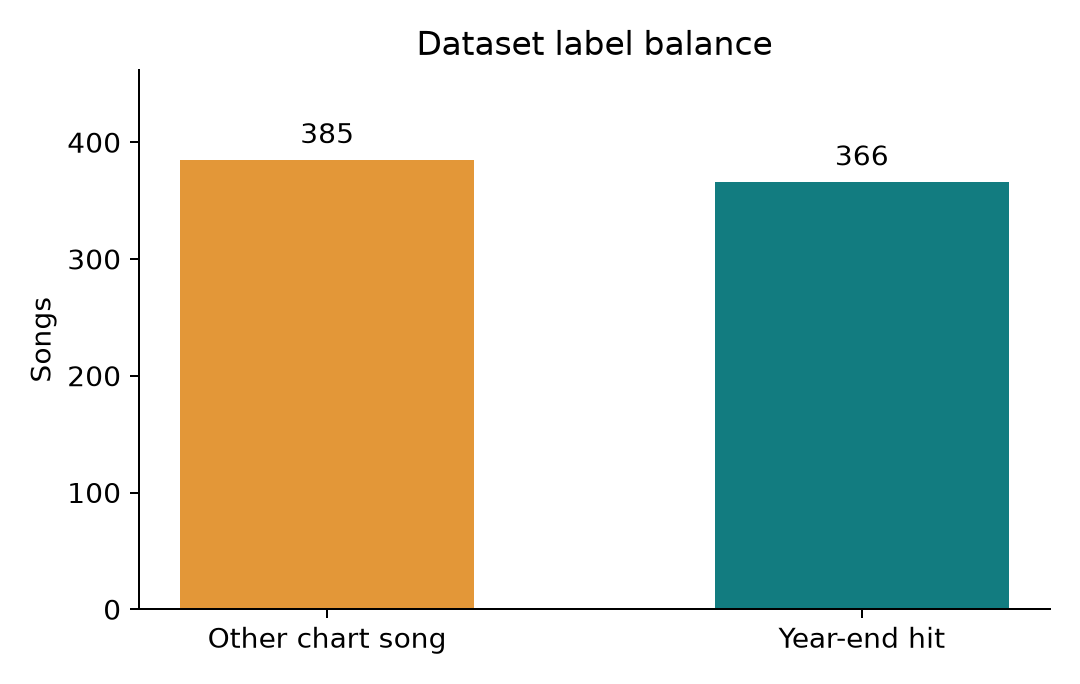

In [2]:
provenance = json.loads((ROOT / 'data/provenance.json').read_text())
display(pd.Series({key: provenance[key] for key in ['source_repository','source_commit','source_sha256','prepared_sha256']}))
audit = data_audit(data)
display(pd.Series(audit))
display(data[['track_id','artist','title','label']].head())
display(Image(filename=str(RESULTS / 'figures/class_balance.png')))


## 2. Why 518 features?

There are 74 channels across 11 feature families. Seven summary statistics per channel give 518 values. Chroma describes pitch classes, MFCCs describe timbre, RMS describes energy, and spectral features describe the frequency distribution. The original CSV's `kew` suffix means skewness.


In [3]:
feature_table = pd.DataFrame([{'family': name, 'channels': channels, 'summary_values': channels*7}
                              for name, channels in FEATURE_GROUPS.items()])
display(feature_table)
assert feature_table.summary_values.sum() == 518
print('Statistics: skewness, min, max, standard deviation, mean, median, kurtosis')


,family,channels,summary_values
0,chroma_stft,12,84
1,chroma_cqt,12,84
2,chroma_cens,12,84
3,mfcc,20,140
4,rms,1,7
5,spectral_centroid,1,7
6,spectral_bandwidth,1,7
7,spectral_contrast,7,49
8,spectral_rolloff,1,7
9,tonnetz,6,42


Statistics: skewness, min, max, standard deviation, mean, median, kurtosis


## 3. Separate artists before training

The first fold of shuffled five-fold StratifiedGroupKFold (seed 42) is the fixed test partition. The remaining songs enter five inner artist-disjoint folds (seed 43). No artist appears on both sides of either split. Exact duplicate feature vectors and artist/title pairs are rejected.

Inside each fold, the Pipeline learns imputation, variance filtering, scaling, and optional PCA from training data only. PCA retains 95% variance for non-tree models. Tree models keep the original feature axes.


,partition,songs,artists
0,train,597,52
1,test,154,19


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('variance', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](518,)","['chroma_stft_kew_0','chroma_stft_min_0','chroma_stft_max_0',..., 'zero_crossing_rate_mean_0','zero_crossing_rate_median_0', 'zero_crossing_rate_kurtosis_0']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,518
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constan

Scaler training samples: 597.0
Training PCA components: 162


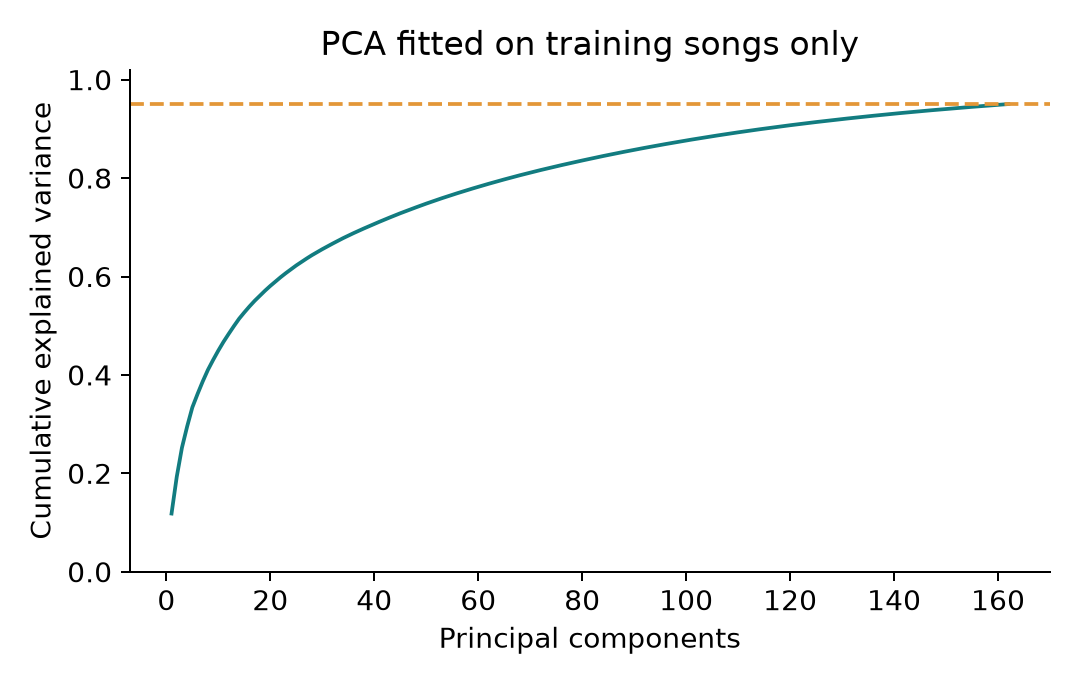

In [4]:
train_idx, test_idx, groups = split_data(data)
assert set(groups[train_idx]).isdisjoint(groups[test_idx])
display(pd.DataFrame([
    {'partition':'train', 'songs':len(train_idx), 'artists':len(set(groups[train_idx]))},
    {'partition':'test', 'songs':len(test_idx), 'artists':len(set(groups[test_idx]))}
]))
display(bundle['pipeline'])
print('Scaler training samples:', bundle['pipeline'].named_steps['scale'].n_samples_seen_)
if 'pca' in bundle['pipeline'].named_steps:
    print('Training PCA components:', bundle['pipeline'].named_steps['pca'].n_components_)
    display(Image(filename=str(RESULTS / 'figures/pca_variance.png')))


## 4. Compare models using training cross-validation

We evaluate logistic regression, LDA, three SVM kernels, random forest, gradient boosting, and a neural network, plus a majority baseline. Hyperparameter grids appear in `chorus_hit/train.py`. The chosen model maximizes mean training CV balanced accuracy. Test performance does not determine the winner.

Balanced accuracy averages both class recalls. A constant majority predictor scores 50%. F1 refers to class 1.


,model,cv_balanced_accuracy,cv_std,test_balanced_accuracy,test_accuracy,test_f1,test_roc_auc,selected
0,Majority baseline,0.500,0.000,0.500,0.506,0.000,0.500,False
1,Logistic regression,0.523,0.040,0.525,0.526,0.503,0.546,False
2,LDA,0.528,0.029,0.526,0.526,0.523,0.525,False
3,Linear SVM,0.496,0.035,0.552,0.552,0.537,0.559,False
4,RBF SVM,0.528,0.036,0.505,0.506,0.449,0.533,False
5,Polynomial SVM,0.536,0.026,0.466,0.468,0.406,0.456,True
6,Random forest,0.533,0.053,0.524,0.526,0.459,0.547,False
7,Gradient boosting,0.518,0.053,0.530,0.532,0.419,0.532,False
8,Neural network,0.499,0.022,0.527,0.526,0.552,0.514,False


Selected model: Polynomial SVM
Chosen parameters: {'model__C': 1.0}


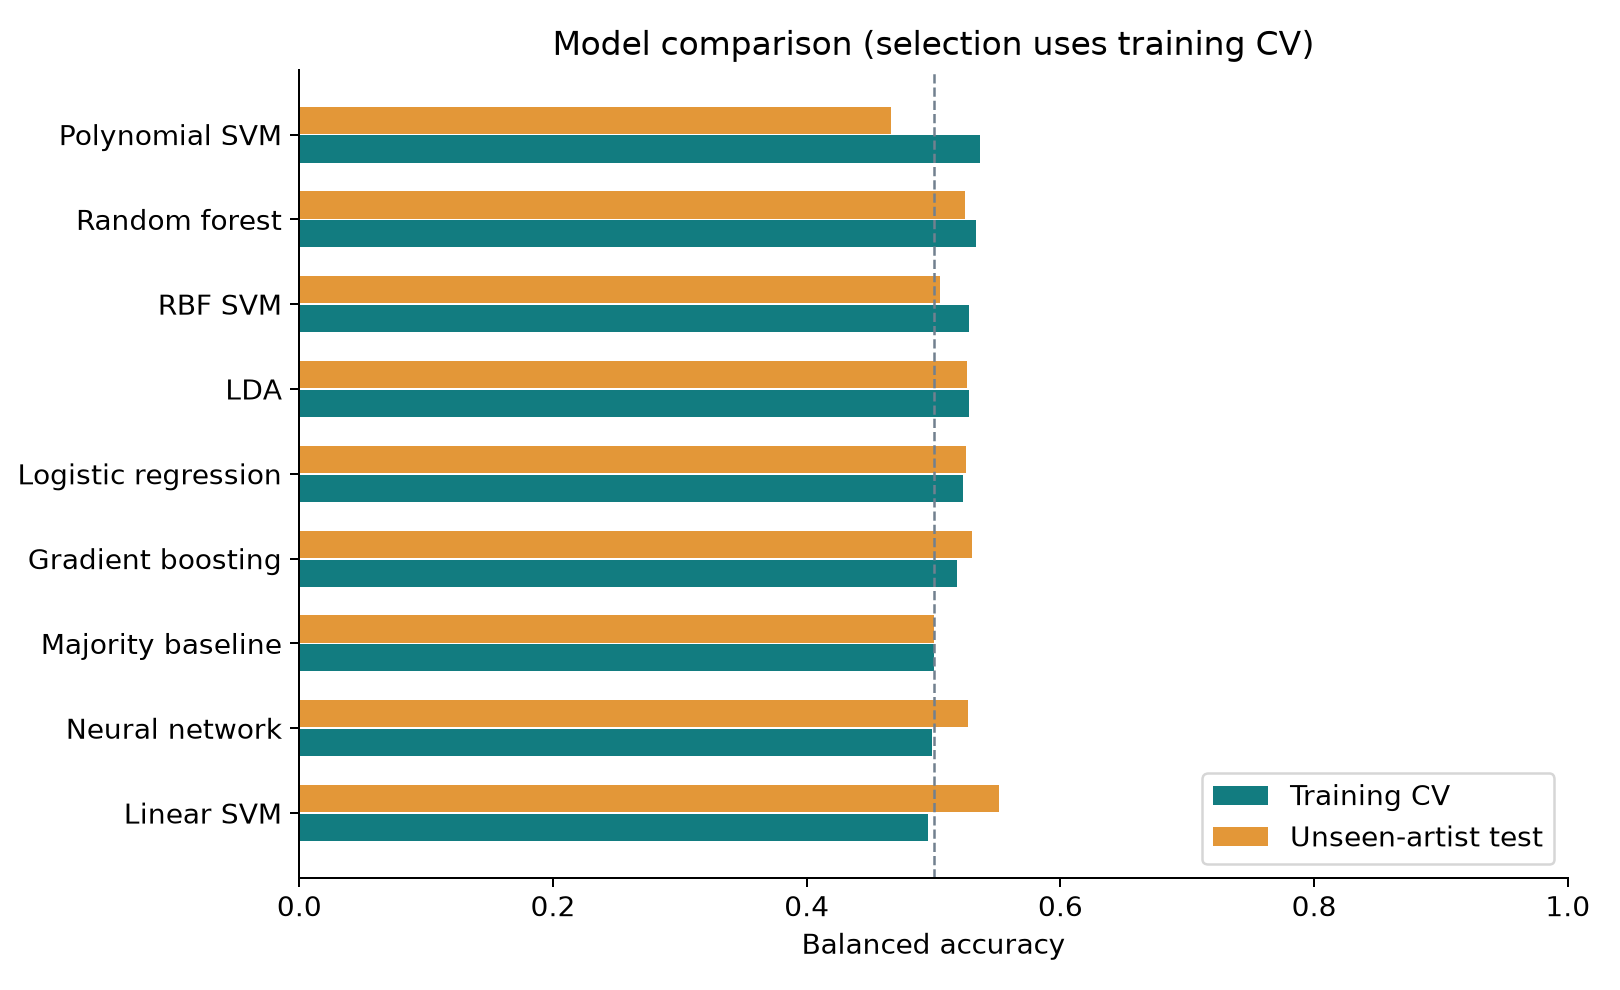

In [5]:
comparison = pd.DataFrame(report['models'])
display(comparison[['model','cv_balanced_accuracy','cv_std','test_balanced_accuracy','test_accuracy','test_f1','test_roc_auc','selected']].round(3))
selected = next(row for row in report['models'] if row['selected'])
print('Selected model:', report['selected_model'])
print('Chosen parameters:', selected['best_params'])
display(Image(filename=str(RESULTS / 'figures/model_comparison.png')))


## 5. Recompute the holdout scores

The saved model contains training track IDs. It remains fitted only on training songs so that the included test demonstration is genuine. The following cell recomputes the metrics directly from model predictions.


accuracy             0.467532
balanced_accuracy    0.466262
precision            0.451613
recall               0.368421
f1                   0.405797
roc_auc              0.455634
dtype: float64

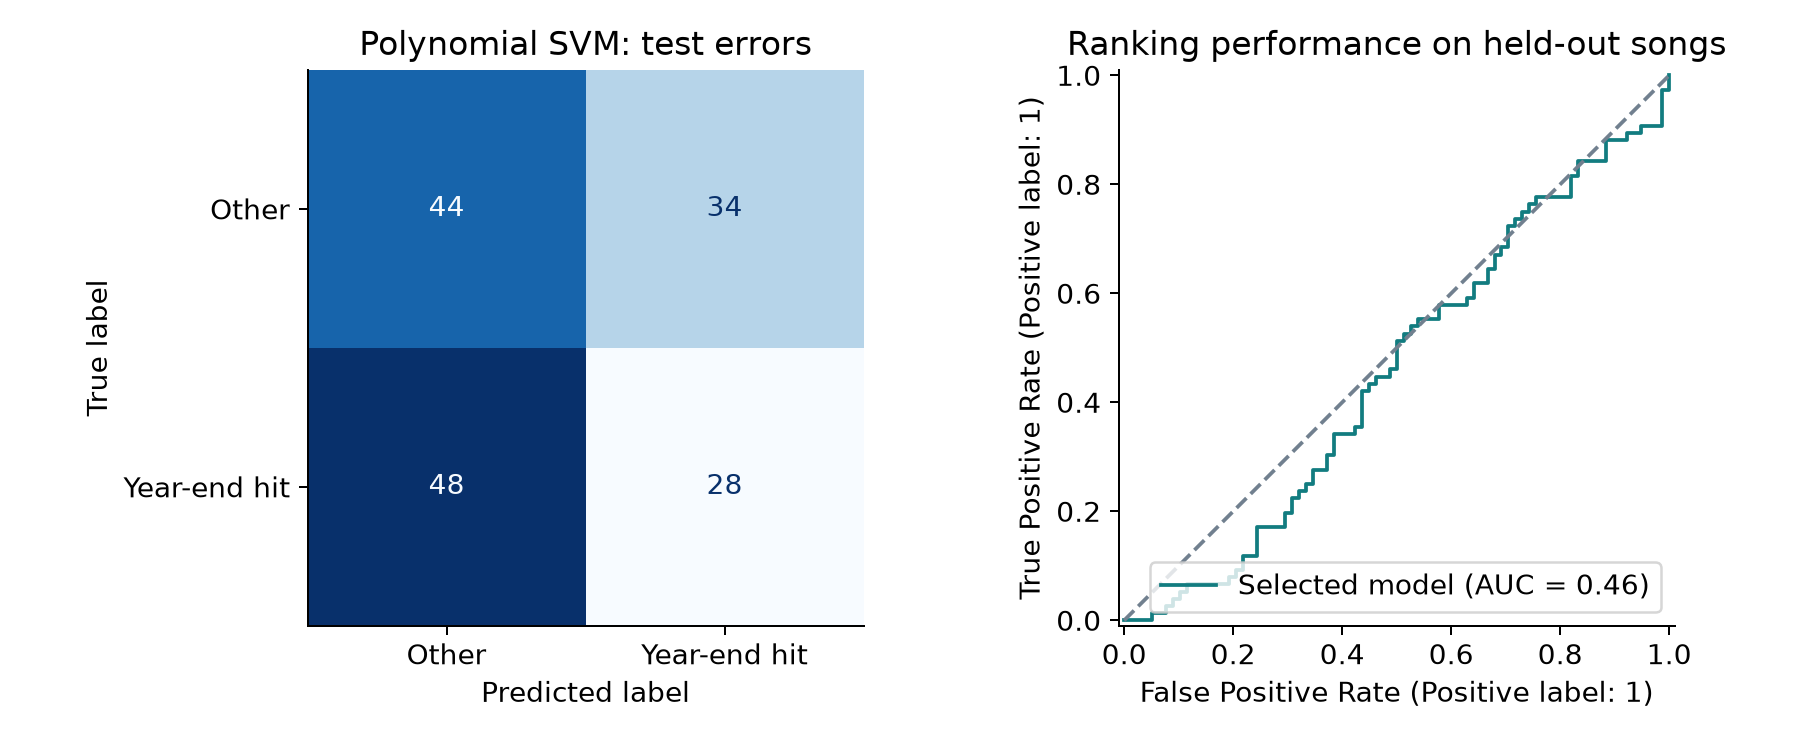

,2.5%,97.5%
accuracy,0.380,0.563
balanced_accuracy,0.387,0.558
precision,0.302,0.614
recall,0.267,0.469
f1,0.298,0.507
roc_auc,0.332,0.592


In [6]:
X_test = data.iloc[test_idx][FEATURE_COLUMNS]
y_test = data.label.iloc[test_idx]
pred = bundle['pipeline'].predict(X_test)
score, score_type = model_scores(bundle['pipeline'], X_test)
recomputed = metrics(y_test, pred, score)
for key, value in recomputed.items():
    assert np.isclose(value, selected['test_' + key])
display(pd.Series(recomputed))
display(Image(filename=str(RESULTS / 'figures/test_evaluation.png')))
display(pd.DataFrame(report['selected_test_ci95_artist_bootstrap'], index=['2.5%','97.5%']).T.round(3))


## 6. Inspect successes and mistakes

Every test prediction is included. The examples below are for explanation, not new evidence about performance. The model score is not a calibrated probability of commercial success.


In [7]:
test_predictions = pd.read_csv(RESULTS / 'test_predictions.csv')
print('Correct predictions')
display(test_predictions[test_predictions.correct].head(3))
print('Incorrect predictions')
display(test_predictions[~test_predictions.correct].head(3))


Correct predictions


,track_id,artist,title,label,prediction,score,correct
0,CH0004,Lil Nas X,Montero (Call Me By Your Name),1,1,0.194928,True
3,CH0011,Billie Eilish,Therefore I Am,1,1,0.406213,True
4,CH0012,Cardi B,Up,1,1,0.037530,True


Incorrect predictions


,track_id,artist,title,label,prediction,score,correct
1,CH0007,Ariana Grande,Positions,1,0,-0.133799,False
2,CH0010,Pop Smoke,What You Know Bout Love,1,0,-0.024621,False
5,CH0021,Ariana Grande,pov,1,0,-0.244465,False


## 7. Audio demonstration

Run `python -m streamlit run app.py`. The app can select a 15-second excerpt and compute 518 features from local audio. Automatic selection finds repeated chroma patterns and may choose a verse, so manual selection is available.

The source recordings and exact original software environment are unavailable. New-audio predictions are exploratory and were not validated against the original recordings. No synthetic audio is included in training. Synthetic tones appear only in signal-processing tests.

## Conclusion

The selected polynomial SVM scores **46.6% balanced accuracy** on the held-out artists, versus **50.0%** for the baseline. The approximate artist-bootstrap interval is **38.7%-55.8%**, including chance performance. The experiment does not demonstrate reliable hit prediction for unfamiliar artists.

A future study should verify chart labels, obtain licensed recordings, consistently re-extract every chorus, and evaluate on a new artist or temporal holdout. It should not optimize against the already inspected test partition.

## References

- [Eric Liu, CS229 report, 2021](https://cs229.stanford.edu/proj2021spr/report2/81974051.pdf)
- [Antonios Malak, source dataset and notebooks](https://github.com/AntoniosMalak/Predicting-Hit-Songs-Using-Repeated-Chorus), Apache-2.0, commit 838e76f
- [Scikit-learn: data leakage and pipelines](https://scikit-learn.org/stable/common_pitfalls.html)

Implementation and materials prepared with OpenAI Codex assistance. Both team members should review the method and rehearse the demonstration.
